# Task B â€” From R to Python: Translating Statistical Analysis
> **BAFAD Accelerated Research Track Â· Fall 2026**

This task bridges your STAT 270 R work with the Python data science ecosystem used in AI research.
You will reproduce three analyses from Assignment 1 â€” originally written in R using `dplyr` and `ggplot2` â€” in Python using `pandas` and `matplotlib`.

**Reference file:** `task_b_r_original.R` (in this folder) â€” contains the complete R code you are translating.

**Data:** `../data/flights.csv` and `../data/airports.csv`

**Submission:** Push your completed notebook to your fork of the starter repository and paste the repo URL into the Canvas assignment.

## Setup

Run this cell first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NAVY = '#021B3A'
BLUE = '#0EA5E9'
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

flights  = pd.read_csv('../data/flights.csv')
airports = pd.read_csv('../data/airports.csv')

print(f'flights:  {flights.shape[0]:,} rows Ã— {flights.shape[1]} columns')
print(f'airports: {airports.shape[0]} rows Ã— {airports.shape[1]} columns')
flights.head(3)

flights:  1,000 rows Ã— 19 columns
airports: 35 rows Ã— 8 columns


,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,7,27,669,645,24,1083,1059,45,F9,4502,N772AA,LGA,MKE,254,2294,6,45,2013-07-27 06:00:00
1,2013,7,11,693,715,-22,1334,1356,-9,YV,8275,N414EF,LGA,MCO,401,3254,7,15,2013-07-11 07:00:00
2,2013,3,3,1466,1415,51,2071,2020,58,F9,6396,N348AE,JFK,PHX,365,3196,14,15,2013-03-03 14:00:00


---
## Question 2 â€” Frequency Tables and Proportions (10 pts)

### Part A (4 pts)
Compute the **number of flights** and the **proportion of all flights** operated by each carrier.
Display the result sorted from most to least flights.

**R equivalent:**
```r
flights |> count(carrier, sort = TRUE) |> mutate(prop = n / sum(n))
```

*Python hints:*
- `flights['carrier'].value_counts()` gives counts sorted descending.
- Divide by `len(flights)` to get proportions.
- Build a `pd.DataFrame` with columns `carrier`, `n`, `prop`.

In [2]:
carrier_counts = flights['carrier'].value_counts(dropna=False).rename_axis('carrier').reset_index(name='n')
carrier_counts['prop'] = carrier_counts['n'] / len(flights)
carrier_counts

,carrier,n,prop
0,F9,74,0.074
1,B6,72,0.072
2,US,71,0.071
3,UA,68,0.068
4,DL,67,0.067
5,MQ,66,0.066
6,VX,64,0.064
7,9E,63,0.063
8,YV,61,0.061
9,EV,61,0.061


**Answer** — Which carrier operated the most flights? What was its approximate share?

F9 operated the most flights in this supplied sample: 74 of 1,000 flights, or 7.4%. This describes the provided subset, not the full nycflights13 dataset.

### Part B (6 pts)
Compute the **proportion of flights that arrived late** (`arr_delay > 0`) for each carrier,
sorted from highest to lowest late-arrival rate.

**R equivalent:**
```r
flights |> group_by(carrier) |>
  summarise(late_rate = mean(arr_delay > 0, na.rm = TRUE)) |>
  arrange(desc(late_rate))
```

*Python hints:*
- `(flights['arr_delay'] > 0)` produces a boolean Series; take `.mean()` per group.
- Use `groupby('carrier').apply(...)` or `groupby('carrier')['arr_delay'].agg(...)`.

In [3]:
# Drop missing delays BEFORE comparing: NaN > 0 would otherwise become False.
# This reproduces R's mean(arr_delay > 0, na.rm = TRUE).
late_arrivals = (
    flights.groupby('carrier', dropna=False)['arr_delay']
    .agg(lambda delays: delays.dropna().gt(0).mean())
    .rename('late_rate').reset_index()
    .sort_values('late_rate', ascending=False).reset_index(drop=True)
)
late_arrivals

,carrier,late_rate
0,AS,0.735849
1,UA,0.705882
2,YV,0.704918
3,US,0.704225
4,HA,0.689655
5,VX,0.687500
6,DL,0.686567
7,AA,0.672414
8,9E,0.650794
9,EV,0.639344


**Answer** — Which carrier had the worst on-time arrival record?

AS had the highest late-arrival rate in the supplied sample: 39 of 53 flights, approximately 73.6%. Here, late means `arr_delay > 0`; missing delays would be excluded from the denominator.

---
## Question 3 â€” Histogram, Density, and Shape (15 pts)

### Part A (7 pts)
Create a **density histogram** of `dep_delay`, restricted to flights where `dep_delay` is between âˆ’60 and 180 minutes.
Overlay a kernel density estimate (KDE) curve.

- Use `NAVY` (`'#021B3A'`) for the histogram bars.
- Use `BLUE` (`'#0EA5E9'`) for the KDE line.
- Apply `plt.style.use('seaborn-v0_8-whitegrid')` or `plt.rcParams` for a clean background.

**R equivalent:**
```r
flights_filtered |> ggplot(aes(x = dep_delay)) +
  geom_histogram(aes(y = after_stat(density)), fill='#021B3A') +
  geom_density(colour='#0EA5E9') + theme_bw()
```

*Python hints:*
- Filter: `df_filtered = flights[(flights['dep_delay'] >= -60) & (flights['dep_delay'] <= 180)]`
- `ax.hist(..., density=True)` gives a density-normalised histogram.
- `from scipy.stats import gaussian_kde` or `df_filtered['dep_delay'].plot.kde(ax=ax)` for the curve.

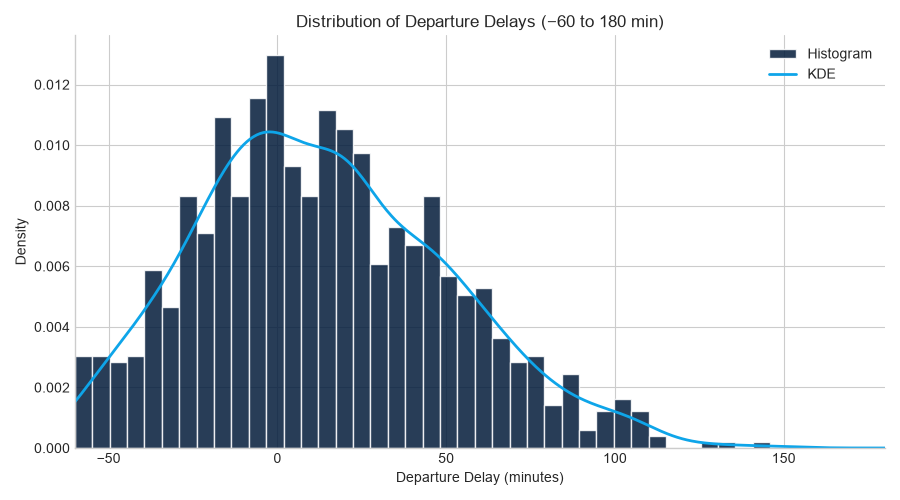

In [4]:
from scipy.stats import gaussian_kde

df_filtered = flights[flights['dep_delay'].between(-60, 180)].copy()
delays = df_filtered['dep_delay'].dropna()
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(delays, bins=40, density=True, color=NAVY, edgecolor='white', alpha=0.85, label='Histogram')
kde = gaussian_kde(delays)
x_grid = np.linspace(-60, 180, 500)
ax.plot(x_grid, kde(x_grid), color=BLUE, linewidth=2, label='KDE')
ax.set_xlim(-60, 180)
ax.set_xlabel('Departure Delay (minutes)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Departure Delays (−60 to 180 min)')
ax.legend()
plt.tight_layout()
plt.show()

### Part B (8 pts)
Compute and report the **median** and **IQR** of `dep_delay` (same filtered range), then describe the distribution in complete sentences addressing: shape, modality, centre, and spread.

In [5]:
median_delay = df_filtered['dep_delay'].median()
q1 = df_filtered['dep_delay'].quantile(0.25)
q3 = df_filtered['dep_delay'].quantile(0.75)
iqr_delay = q3 - q1
print(f'Median departure delay: {median_delay:.1f} min')
print(f'IQR of departure delay: {iqr_delay:.1f} min')
print(f'Q1: {q1:.2f} min; Q3: {q3:.2f} min; n = {len(df_filtered)}')

Median departure delay: 11.0 min
IQR of departure delay: 53.8 min
Q1: -14.00 min; Q3: 39.75 min; n = 958


**Answer** — Shape, modality, centre, spread:

Within the restricted range, the distribution is broadly unimodal with a longer right tail, indicating some relatively long departure delays. The median is 11 minutes, and the middle 50% of delays run from −14 to 39.75 minutes, giving an IQR of 53.75 minutes (53.8 when rounded). Negative delays indicate early departures. These summaries describe the 958 retained observations and exclude delays outside −60 to 180 minutes.

---
## Question 4 â€” Grouped Summaries by Origin Airport (15 pts)

### Part A (7 pts)
For each of the three origin airports (EWR, JFK, LGA), compute the **mean, median, standard deviation, and IQR** of `arr_delay`.
Display the results as a summary table.

**R equivalent:**
```r
flights |> group_by(origin) |>
  summarise(mean_arr=mean(arr_delay,na.rm=T), median_arr=median(...), sd_arr=sd(...), iqr_arr=IQR(...))
```

*Python hints:*
- Use `flights.groupby('origin')['arr_delay'].agg(['mean','median','std'])` and add IQR via `lambda`.
- For IQR: `from scipy.stats import iqr` or `lambda x: x.quantile(0.75) - x.quantile(0.25)`.

In [6]:
# pandas mean/median/std/quantile skip missing values; std uses ddof=1, as R does.
origin_summary = (
    flights.groupby('origin')['arr_delay']
    .agg(mean_arr='mean', median_arr='median', sd_arr='std',
         iqr_arr=lambda delays: delays.quantile(0.75) - delays.quantile(0.25))
    .reset_index()
)
origin_summary

,origin,mean_arr,median_arr,sd_arr,iqr_arr
0,EWR,16.344411,15.0,43.273994,56.0
1,JFK,20.057637,19.0,43.273791,58.0
2,LGA,15.096273,15.0,42.417081,57.5


### Part B (8 pts)
Based on your table, answer in complete sentences:
1. Which airport has the **highest mean** arrival delay? Lowest?
2. For each airport, is the mean **higher or lower** than the median? What does this imply about the shape of each delay distribution?
3. Which airport shows the **greatest spread** (use SD to support your answer)?

**Answer:**

JFK has the highest mean arrival delay (20.06 minutes), and LGA has the lowest (15.10 minutes); EWR averages 16.34 minutes. The mean exceeds the median at all three airports: EWR 16.34 versus 15, JFK 20.06 versus 19, and LGA 15.10 versus 15 minutes. This is consistent with some right-tail influence, although LGA’s difference is very small and mean-versus-median alone does not establish distribution shape. EWR has the largest sample SD (43.273994 minutes), just above JFK (43.273791); both round to 43.27, so their spreads are effectively tied at ordinary reporting precision. LGA’s SD is 42.417081 minutes.

---
## Reflection (not graded â€” but read before Task C)

Take 5 minutes to jot down:
- What was the hardest part of translating R to Python?
- What Python feature did you find most useful or surprising?
- How do `pandas` and `dplyr` differ in their approach to grouped operations?

You will expand on this in `task-c/reflection.md`.

### Translation notes

The main semantic pitfall is missing-value handling: comparing a floating-point NaN with zero produces False in pandas, so missing values must be removed before computing the late-arrival fraction. Named aggregations make grouped summaries readable: pandas uses `groupby(...).agg(...)`, while dplyr uses `group_by(...) |> summarise(...)`. pandas commonly uses an index for group labels; `reset_index()` restores ordinary columns. SciPy and R use different default KDE bandwidth rules, so their curves need not match exactly even when they use the same data.

### Translation notes

The main semantic pitfall is missing-value handling: comparing a floating-point NaN with zero produces False in pandas, so missing values must be removed before computing the late-arrival fraction. Named aggregations make grouped summaries readable: pandas uses `groupby(...).agg(...)`, while dplyr uses `group_by(...) |> summarise(...)`. pandas commonly uses an index for group labels; `reset_index()` restores ordinary columns. SciPy and R use different default KDE bandwidth rules, so their curves need not match exactly even when they use the same data.